In [3]:
# Create students.csv file
csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

with open("/content/students.csv", "w") as f:
    f.write(csv_content)

print("students.csv created successfully!")

import pandas as pd

# Load the dataset
df = pd.read_csv("/content/students.csv")

# 1. Print first 5 rows
print("First 5 rows:")
print(df.head())

# 2. Print shape and data types
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nData types:")
print(df.dtypes)

# 3. Summary statistics
print("\nSummary Statistics:")
print(df.describe().round(2))

# 4. Pass/Fail count
print("\nPass/Fail Count:")
print(df['passed'].value_counts())

# 5. Average score per subject for pass vs fail
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores - Passing students:")
print(df[df['passed'] == 1][subject_cols].mean().round(2))

print("\nAverage scores - Failing students:")
print(df[df['passed'] == 0][subject_cols].mean().round(2))

# 6. Student with highest overall average
df['temp_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['temp_avg'].idxmax()]
print(f"\nTop student: {top_student['name']} with average {top_student['temp_avg']:.2f}")
df = df.drop(columns=['temp_avg'])

students.csv created successfully!
First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: 15 rows x 9 columns

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statist

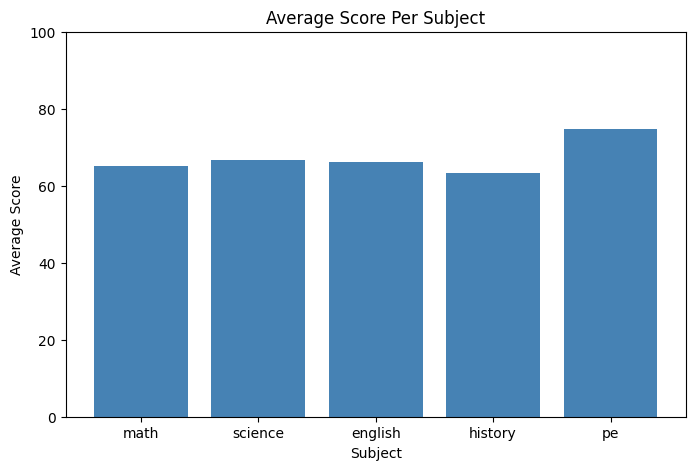

Plot 1 saved!


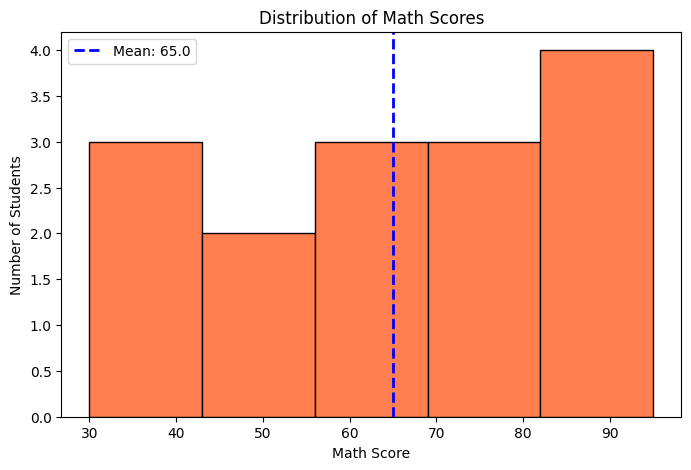

Plot 2 saved!


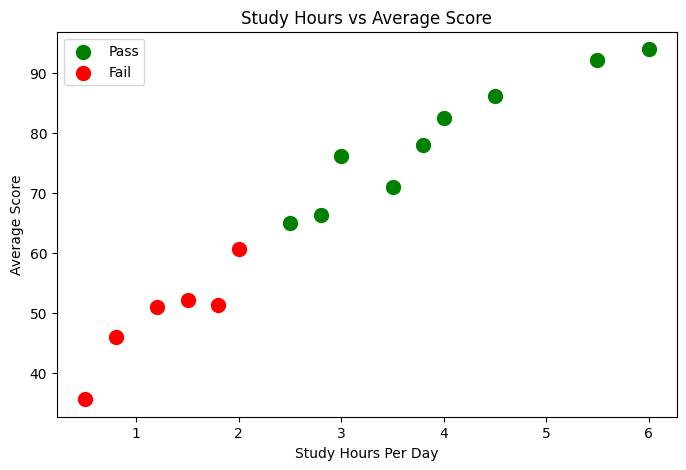

Plot 3 saved!


/tmp/ipykernel_1392/2047947959.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


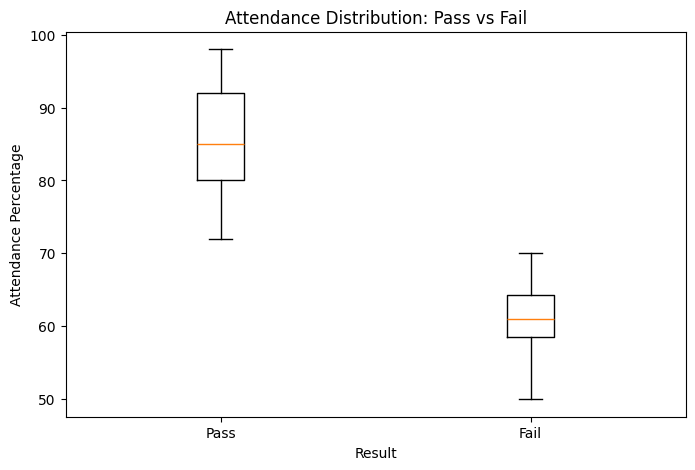

Plot 4 saved!


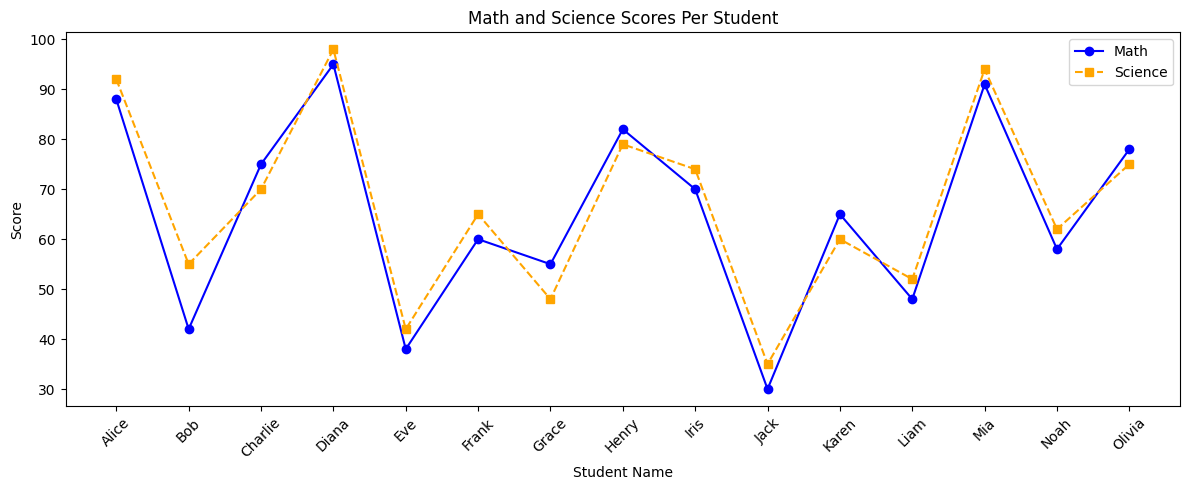

Plot 5 saved!


In [8]:
import matplotlib.pyplot as plt

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# ============================================================
# PLOT 1 - Bar Chart: Average score per subject
# ============================================================
avg_per_subject = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_cols, avg_per_subject, color='steelblue')
plt.title("Average Score Per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.savefig("/content/plot1_bar.png")
plt.show()
print("Plot 1 saved!")

# ============================================================
# PLOT 2 - Histogram: Distribution of math scores
# ============================================================
mean_math = df['math'].mean()

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')
plt.axvline(mean_math, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_math:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("/content/plot2_histogram.png")
plt.show()
print("Plot 2 saved!")

# ============================================================
# PLOT 3 - Scatter Plot: Study hours vs Average score
# ============================================================
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'],
            color='green', label='Pass', s=100)
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'],
            color='red', label='Fail', s=100)
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("/content/plot3_scatter.png")
plt.show()
print("Plot 3 saved!")

# ============================================================
# PLOT 4 - Box Plot: Attendance for Pass vs Fail
# ============================================================
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.savefig("/content/plot4_box.png")
plt.show()
print("Plot 4 saved!")

# ============================================================
# PLOT 5 - Line Plot: Math and Science scores per student
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', color='blue', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', color='orange', label='Science')
plt.title("Math and Science Scores Per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("/content/plot5_line.png")
plt.show()
print("Plot 5 saved!")

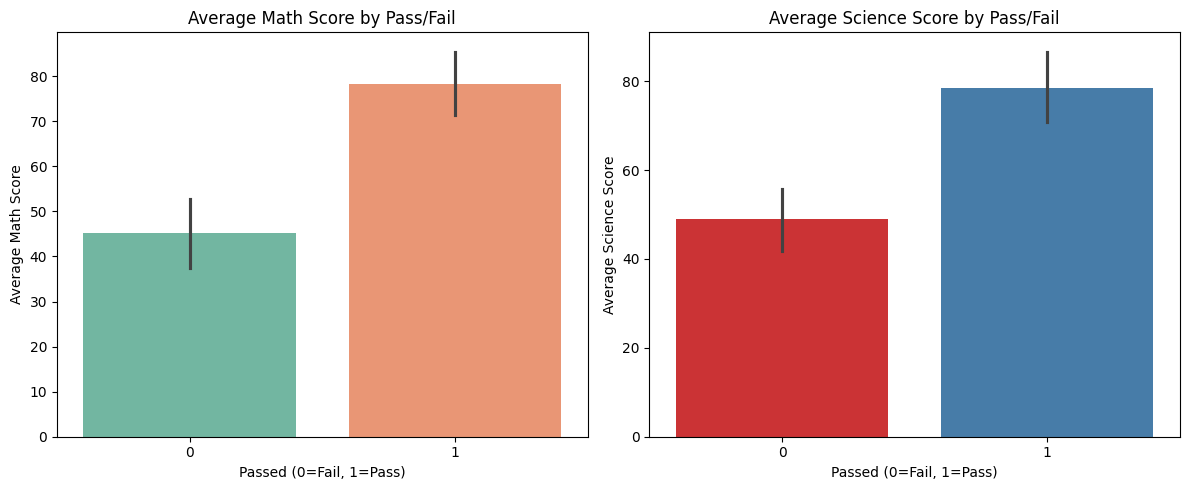

Plot 6 saved!


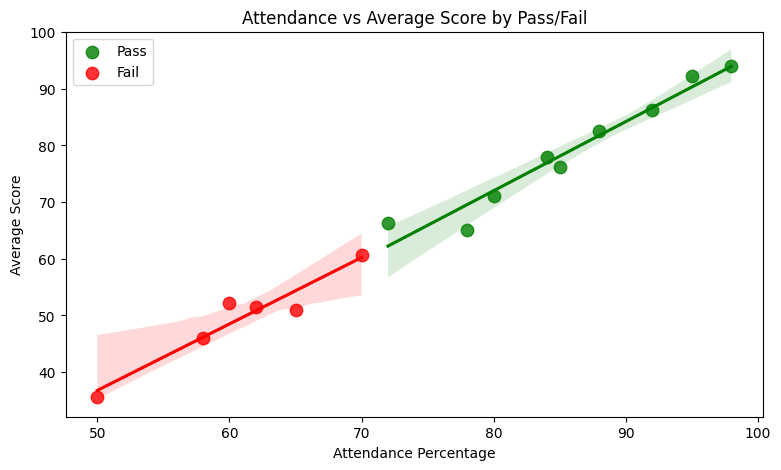

Plot 7 saved!


In [17]:
# ============================================================
# PLOT 6 - Seaborn Bar Plot: Math and Science by Pass/Fail
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Math scores by passed
sns.barplot(data=df, x='passed', y='math', hue='passed', legend=False, ax=ax1, palette='Set2')
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Average Math Score")

# Science scores by passed
sns.barplot(data=df, x='passed', y='science', hue='passed', legend=False, ax=ax2, palette='Set1')
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Average Science Score")

plt.tight_layout()
plt.savefig("/content/plot6_seaborn_bar.png")
plt.show()
print("Plot 6 saved!")

# ============================================================
# PLOT 7 - Seaborn Scatter: Attendance vs Average Score
# ============================================================
plt.figure(figsize=(9, 5))

sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            label='Pass', color='green', scatter_kws={'s': 80})
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            label='Fail', color='red', scatter_kws={'s': 80})

plt.title("Attendance vs Average Score by Pass/Fail")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("/content/plot7_seaborn_scatter.png")
plt.show()
print("Plot 7 saved!")

# Seaborn vs Matplotlib comparison comment
# Seaborn required less code to produce polished plots compared to Matplotlib.
# For example, regplot() automatically added regression lines without extra steps.
# Matplotlib gave more manual control but required more lines of code for styling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



Training samples : 12
Testing samples  : 3
Training Accuracy: 100.00%
Test Accuracy: 100.00%

Predictions on test students:
--------------------------------------------------
Jack       | Actual: 0 | Predicted: 0 | ✅ Correct
Liam       | Actual: 0 | Predicted: 0 | ✅ Correct
Alice      | Actual: 1 | Predicted: 1 | ✅ Correct
Feature Importance (sorted by absolute value):
---------------------------------------------
english                   0.8125  → Push to Pass
attendance_pct            0.5219  → Push to Pass
study_hours_per_day       0.4844  → Push to Pass
pe                        0.4750  → Push to Pass
math                      0.4379  → Push to Pass
science                   0.3230  → Push to Pass
history                   0.2629  → Push to Pass


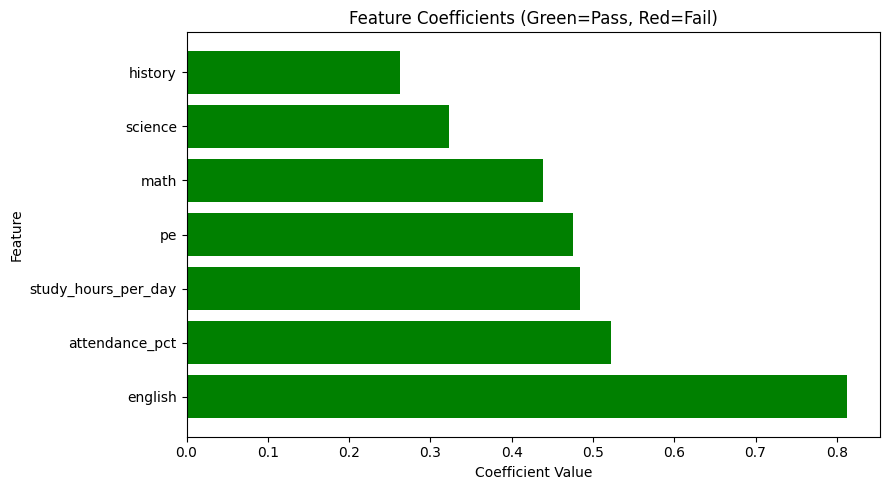

Feature importance plot saved!
New Student Prediction:
----------------------------------------
Features : Math=75, Science=70, English=68
           History=65, PE=80, Attendance=82%, Study=3.2hrs

Prediction  : Pass ✅
Probability : Fail=9.20% | Pass=90.80%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
# ============================================================
# TASK 4 - Machine Learning
# ============================================================

# Step 1 - Prepare data
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
# Step 2 - Train the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Print training accuracy
train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Step 3 - Evaluate the model
y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Print each test student with actual vs predicted
print("\nPredictions on test students:")
print("-" * 50)
test_names = df.loc[X_test.index, 'name']
for name, actual, predicted in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{name:<10} | Actual: {actual} | Predicted: {predicted} | {result}")

    # Step 4 - Feature Importance
import numpy as np

coefficients = model.coef_[0]
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("Feature Importance (sorted by absolute value):")
print("-" * 45)
for feature, coef in feature_importance:
    direction = "→ Push to Pass" if coef > 0 else "→ Push to Fail"
    print(f"{feature:<25} {coef:.4f}  {direction}")

# Plot feature coefficients
features = [f[0] for f in feature_importance]
coefs    = [f[1] for f in feature_importance]
colors   = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(9, 5))
plt.barh(features, coefs, color=colors)
plt.title("Feature Coefficients (Green=Pass, Red=Fail)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("/content/plot8_feature_importance.png")
plt.show()
print("Feature importance plot saved!")

# Step 5 (Bonus) - Predict for a new student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale the new student data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

print("New Student Prediction:")
print("-" * 40)
print(f"Features : Math=75, Science=70, English=68")
print(f"           History=65, PE=80, Attendance=82%, Study=3.2hrs")
print(f"\nPrediction  : {'Pass ✅' if prediction[0] == 1 else 'Fail ❌'}")
print(f"Probability : Fail={probability[0][0]:.2%} | Pass={probability[0][1]:.2%}")